In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from VAE import VAE, kl_loss_function, mse_loss_function

In [2]:
device = torch.device('cuda')
batch_size = 120
epochs = 30

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((32, 32)) 
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

In [4]:
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

In [5]:
# Verificar que el dataloader funciona
for batch_idx, (data, target) in enumerate(dataloader):
    print(f"Lote {batch_idx}: Tamaño de entrada: {data.size()}, Tamaño de etiquetas: {target.size()}")
    break  # Solo imprimir el primer lote

Lote 0: Tamaño de entrada: torch.Size([120, 1, 32, 32]), Tamaño de etiquetas: torch.Size([120])


In [6]:
image_shape = list(data.shape)
image_shape

[120, 1, 32, 32]

In [7]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
            x_bar = model.decoder(z_sample).to(device)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [8]:
model = VAE(image_channels=1, down_channels=[32, 64, 128], mid_channels=[128, 128],
            down_sample=[True, True], attn_down=[False, False], norm_channels=32, 
            num_heads=16,num_down_layers=1, num_mid_layers=1, num_up_layers=1, latent_channels=5).to(device)
optimizer = torch.optim.Adam(model.parameters())
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=epochs)

Epoch 29 - Training: 100%|██████████| 500/500 [04:24<00:00,  1.89it/s, mse_loss=1.56e+3, kl_loss=1.64e+3, loss=3.2e+3] 


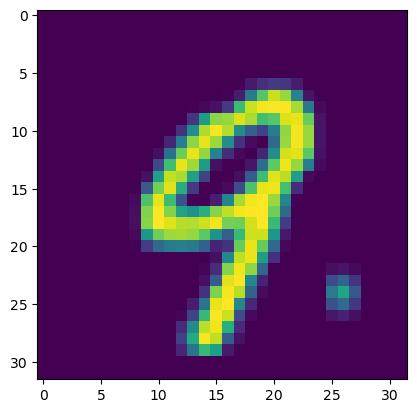

In [20]:
import matplotlib.pyplot as plt

x = data[2]
x = x.unsqueeze(0)
plt.imshow(x[0].permute(1, 2, 0))

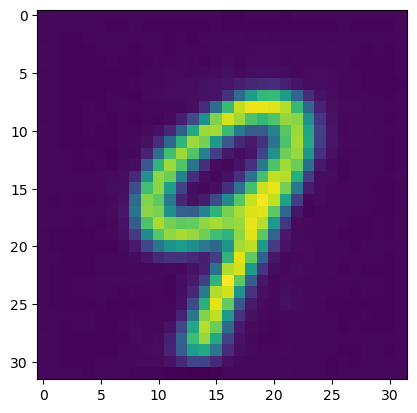

In [21]:
model.eval()

x = x.to(device)
mean, log_var = model.encoder(x)
z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
x_bar = model.decoder(z_sample)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())
